<h2>Data Analytics- notebook, Compost coders</h2>

<h4><b>Dataset name: Short description</b></h4>

Dataset analysis about Lapin AMK composters

<h4><b>Data source (url):</b></h4>

https://data.mendeley.com/datasets/dgxxj2pk8s/2

<h4><b>Data format:</b></h4>

Describe file structure here.

<h4><b>Data description, features and limitations:</b></h4>

NOTE: AI has been used heavily in this notebook to help create code and analyse data

<h3 style="color: red"><b>Code: importing modules, custom functions and loading the data</b></h3>

In [244]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl

In [245]:
# Load the dataset
df = pd.read_excel('../../data/compost_dataset_4.xlsx')

<h3 style="color: red"><b>Code: Data clean-up procedure</b></h3>

In [246]:
df.columns

Index(['Hour', 'Minutes', 'Temp. Heater', 'Temp. Biopila', 'Humidity',
       'Input_Air', 'Entrada Heat', 'Days', 'Unnamed: 8'],
      dtype='str')

In [247]:
# Example: define a starting date
start_date = pd.Timestamp("2026-01-01")

df["timestamp"] = (
    start_date
    + pd.to_timedelta(df["Days"], unit="D")
    + pd.to_timedelta(df["Hour"], unit="h")
    + pd.to_timedelta(df["Minutes"], unit="m")
)

In [248]:
df.drop(columns=["Days","Hour", "Minutes", "Entrada Heat", "Unnamed: 8"], inplace=True)

In [249]:
df.columns = df.columns.str.replace('Temp. Heater', 'incoming_heater_temp_C')
df.columns = df.columns.str.replace('Temp. Biopila', 'internal_compost_temp_C')

In [250]:
# Use the new total_hours column
selected_columns = ['timestamp', 'incoming_heater_temp_C', 'internal_compost_temp_C', 'Humidity']

# filter out the columns we want to see
filtered_df = df[selected_columns]

# Define start and end dates
start_date = '2026-01-01'
end_date   = '2026-01-16'

# Filter the data
filtered_df = filtered_df[(filtered_df['timestamp'] >= start_date) & (filtered_df['timestamp'] <= end_date)]

# switch to long format with melt, easier to visualize with multiline plots
# see the lecture example of ricebeefcoffee_revisited for another example!
df_long = pd.melt(
    filtered_df,
    id_vars=["timestamp"],
    var_name="Sensor",
    value_name="Value"
)

In [251]:
df

,incoming_heater_temp_C,internal_compost_temp_C,Humidity,Input_Air,timestamp
0,51.3,27.5,81.1,100,2026-01-02 11:45:00
1,55.1,27.2,82.5,100,2026-01-02 11:50:00
2,50.8,27.2,81.9,100,2026-01-02 11:55:00
3,50.0,27.2,81.0,100,2026-01-02 12:00:00
4,51.5,27.2,83.3,100,2026-01-02 12:05:00
...,...,...,...,...,...
4297,25.4,31.5,22.1,0,2026-01-16 10:00:00
4298,25.3,31.7,29.8,0,2026-01-16 10:05:00
4299,25.7,30.1,51.0,0,2026-01-16 10:10:00
4300,26.0,30.0,52.4,0,2026-01-16 10:15:00


<h3 style="color: red"><b>Code: Data analysis</b></h3>

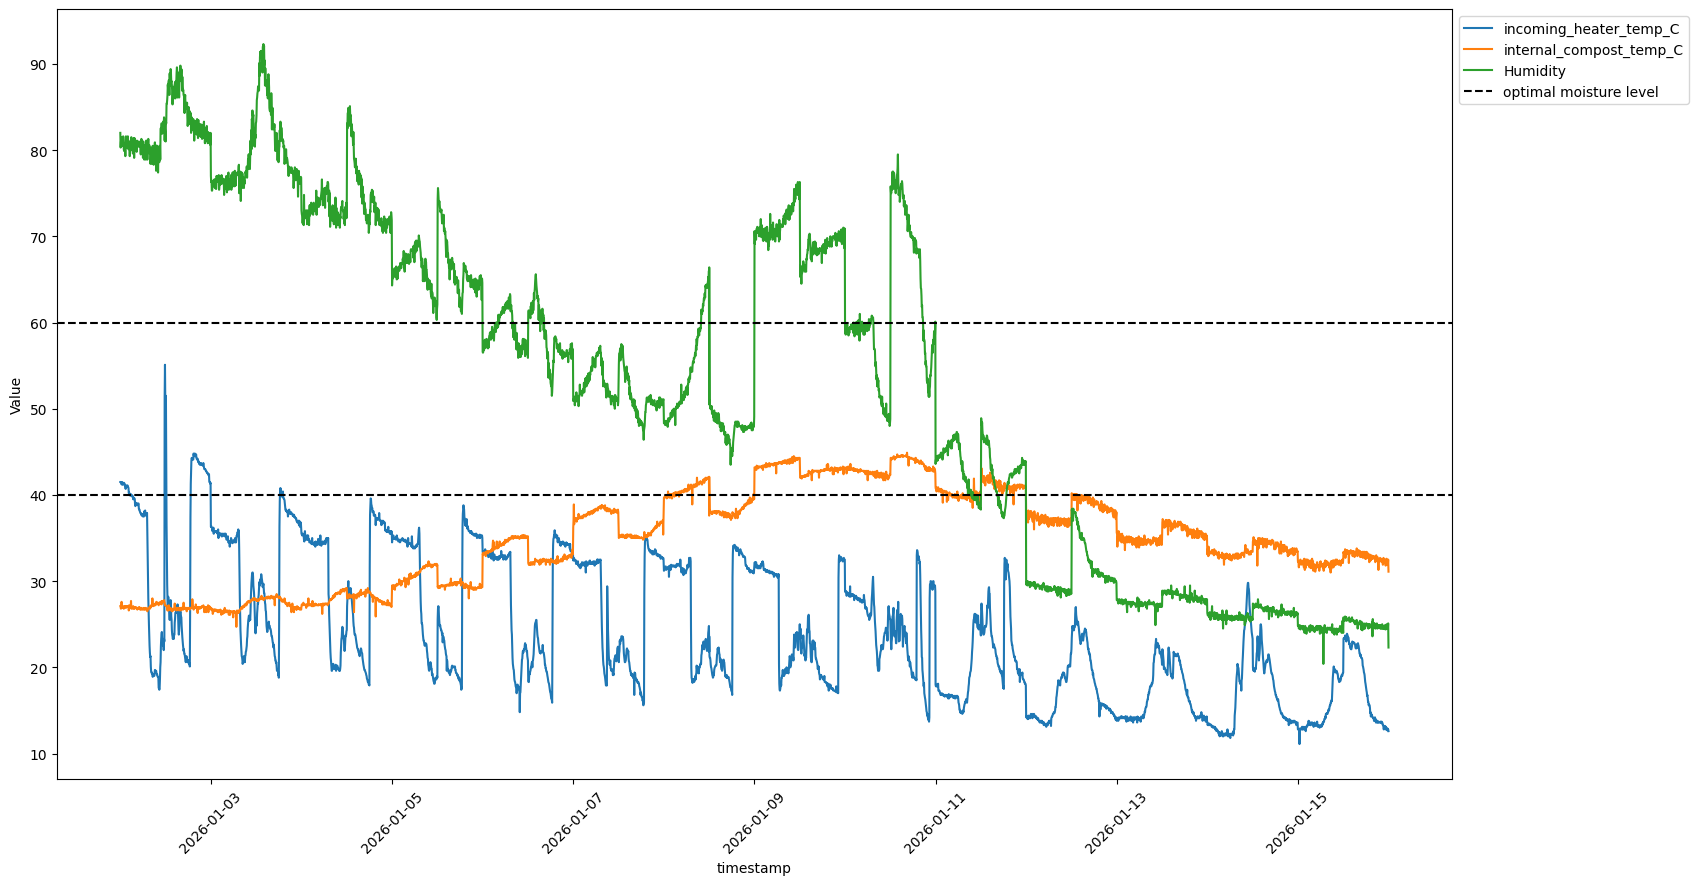

In [253]:
 # increase the plot size, also place the legend outside the plot
# also rotate x-labels 45 degrees for easier readability
plt.figure(figsize=(18, 10))
plot = sns.lineplot(data=df_long, x="timestamp", y="Value", hue="Sensor", errorbar=None)
plt.xticks(rotation=45)
plt.axhline(y=40, color='black', linestyle='--', label='optimal moisture level')
plt.axhline(y=60, color='black', linestyle='--')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

<h3 style="color: red"><b>Results and summary:</b></h3>

<h3><strong>Overview</strong></h3>
The chart tracks moisture levels across six sensor positions in two composters (C1 and C2) at three vertical layers each: Low, Mid, and Upper.

<h3><strong>Key Observations</strong></h3> <h4><strong>Dry hemp as a structural component</strong></h4> Dry hemp appears to function effectively as a bulking agent, improving aeration and providing carbon for microbial activity. However, when added dry and not sufficiently mixed, it contributes to uneven moisture distribution, leading to dry upper layers and wetter lower zones.
<h4><strong>Moisture distribution</strong></h4> Moisture trends indicate a clear stratification within the composters. Lower layers tend to retain significantly more moisture over time, while middle and upper layers remain comparatively dry. Although the exact moisture values may be inaccurate due to sensor limitations, the overall pattern is consistent.

This suggests that water is accumulating in the bottom layers, likely due to gravity and leachate movement, while the upper layers are not receiving or retaining sufficient moisture.

<h4><strong>Temperature development</strong></h4> Temperature data shows a strong initial peak of around 60 °C, indicating a healthy microbial response at the start of the composting process. This confirms that the combination of biowaste and hemp provides suitable conditions for thermophilic activity.

However, temperatures decline relatively quickly after this peak and gradually approach ambient levels. A smaller secondary increase in temperature is observed later, but it is weaker and less sustained.

<h4><strong>Temperature–moisture relationship</strong></h4> The temperature trends closely reflect the moisture imbalance. The initial high temperatures correspond to a period when conditions were more favorable across the compost mass. As moisture became unevenly distributed, microbial activity decreased, particularly in the drier upper layers.

Later-stage activity appears to be concentrated mainly in the lower layers, where moisture levels remained more stable. This results in reduced overall efficiency, as composting is no longer occurring uniformly throughout the material.

<h4><strong>Overall interpretation</strong></h4> The composting process is biologically active and starts under favorable conditions, but its performance declines due to physical and operational factors rather than material composition.

The main limiting factors are:

Overcrowding, especially at the beginning, reducing aeration
Insufficient mixing, leading to vertical stratification
Uneven moisture distribution, with wet lower layers and dry upper layers
<h4><strong>Key takeaway</strong></h4>

The system functions as intended in principle, but composting becomes uneven and localized over time, with most biological activity occurring in the lower layers due to better moisture conditions, while upper layers remain relatively inactive.

<h3 style="color: red"><b>Ideas for further improvements:</b></h3>

Turning/aerating the compost more frequently would help redistribute moisture from the saturated lower layers to the dry upper layers, bringing more sensors into the optimal 40–60% band and improving overall decomposition efficiency.